# Counterfactual Simulations

In [1]:
import sys
from pathlib import Path

# Add the project root to Python path (for Jupyter notebooks)
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [2]:
import numpy as np

# package imports
from counterfactual_fraud_model.config import RetrainingStrategy

# import ope simulation function
from notebooks.utils.simulation_analysis import run_simulations
from notebooks.utils.synthetic_simulation_analysis import run_exploration_rate_simulations
from notebooks.utils.retraining_simulation_analysis import run_retraining_simulations, RetrainingSimulationAnalyzer

# Import common analysis functions
from notebooks.utils.common_analysis import (
    plot_model_scores_histogram,
    plot_calibration_curve,
    plot_precision_recall_curve,
    create_policy_metrics_table,
    plot_ope_metrics,
    create_standard_data_summary_table,
    create_synthetic_data_summary_table,
)

## Basic OPE Simulations

In [ ]:
exploration_rates = np.linspace(0.01, 0.2, 5)
random_state = 667

results, reference_data = run_simulations(cutoff=0.05, sample_size=50_000,
                                          exploration_rates=exploration_rates, random_state=random_state,)

Running 5 simulations...
Running simulation 1/5 with exploration_rate=0.010
Running simulation 2/5 with exploration_rate=0.058
Running simulation 3/5 with exploration_rate=0.105
Running simulation 4/5 with exploration_rate=0.153
Running simulation 5/5 with exploration_rate=0.200


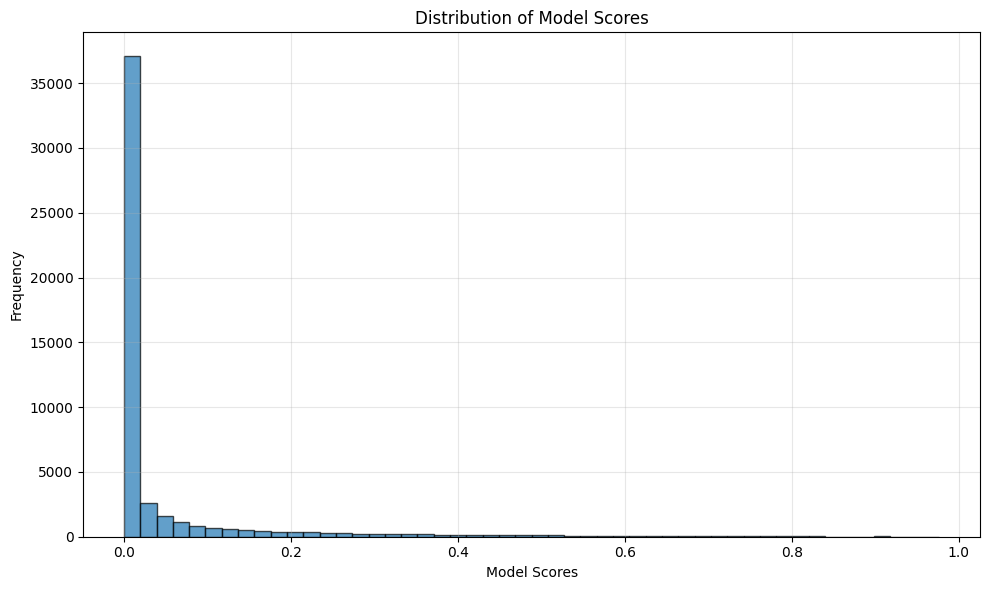

In [7]:
plot_model_scores_histogram(reference_data)

In [8]:
pipeline_params = results[0]['parameters']
summary_table = create_standard_data_summary_table(reference_data, pipeline_params)
summary_table

,Metric,Value
0,Total Transactions,50000
1,True Fraud Rate,0.0535
2,Alpha,0.1
3,Beta,2.0
4,Mean,-0.5
5,SD,0.5
6,Sample Size,50000


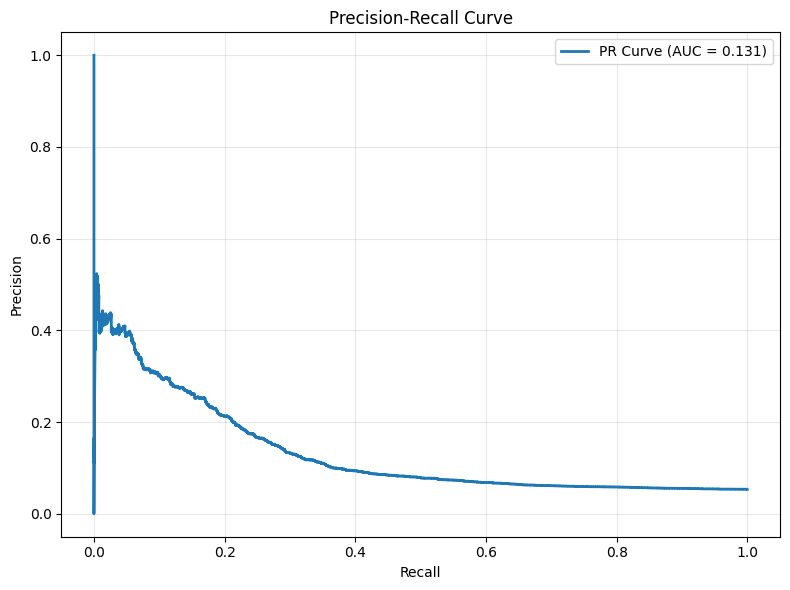

In [12]:
plot_precision_recall_curve(reference_data)

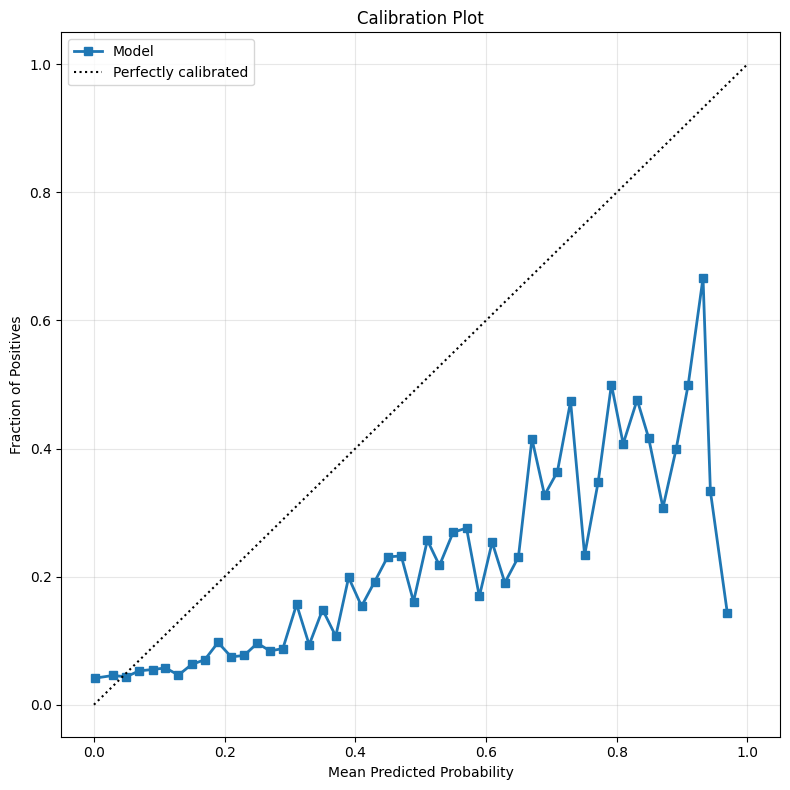

In [13]:
plot_calibration_curve(reference_data)

In [11]:
policy_table = create_policy_metrics_table(results)
policy_table

,exploration_rate,allow_rate,block_rate,fraud_rate_overall,fraud_rate_allowed,total_transactions,allowed_transactions,blocked_transactions
0,0.0100,0.81536,0.18464,0.05348,0.042313,50000,40768,9232
1,0.0575,0.82478,0.17522,0.05348,0.043018,50000,41239,8761
2,0.1050,0.83330,0.16670,0.05348,0.043538,50000,41665,8335
3,0.1525,0.84118,0.15882,0.05348,0.044342,50000,42059,7941
4,0.2000,0.85038,0.14962,0.05348,0.044780,50000,42519,7481


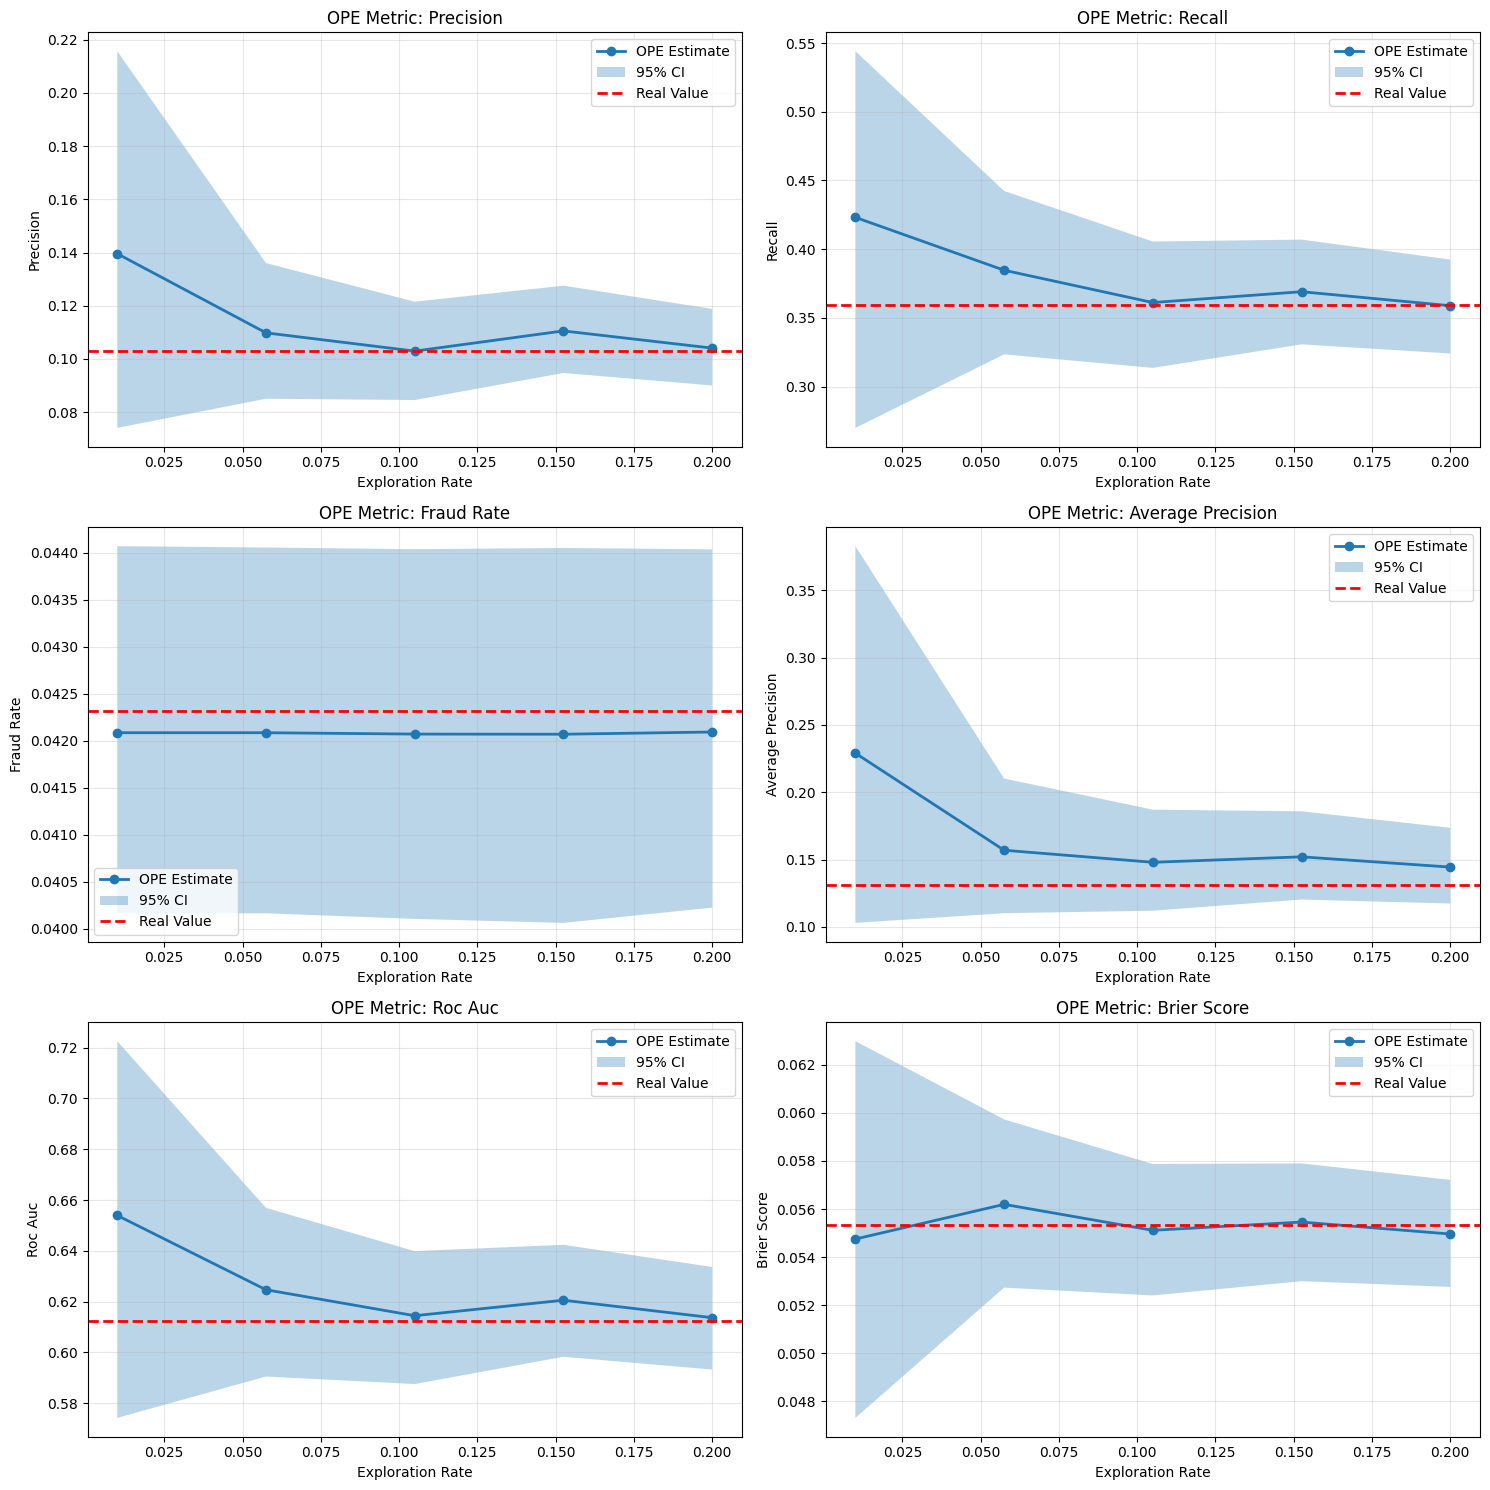

In [14]:
plot_ope_metrics(results)

## Synthetic OPE Simulations

In [3]:
exploration_rates = np.linspace(0.01, 0.2, 5)
random_state = 667
n_samples = 50_000
cutoff = 0.05
model_type = "lightgbm"

results, reference_data = run_exploration_rate_simulations(cutoff=cutoff, n_samples=n_samples, model_type=model_type,
                                                           exploration_rates=exploration_rates, random_state=random_state)

Running 5 simulations with lightgbm model...
Running simulation 1/5 with exploration_rate=0.010
Running simulation 2/5 with exploration_rate=0.058
Running simulation 3/5 with exploration_rate=0.105
Running simulation 4/5 with exploration_rate=0.153
Running simulation 5/5 with exploration_rate=0.200


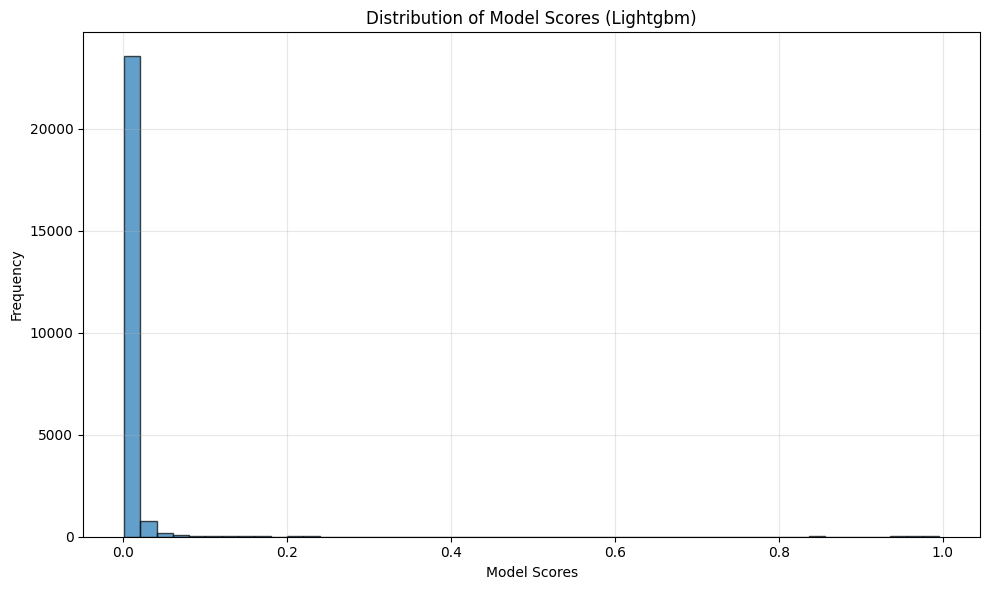

In [4]:
plot_model_scores_histogram(reference_data, f" ({model_type.replace('_', ' ').title()})")

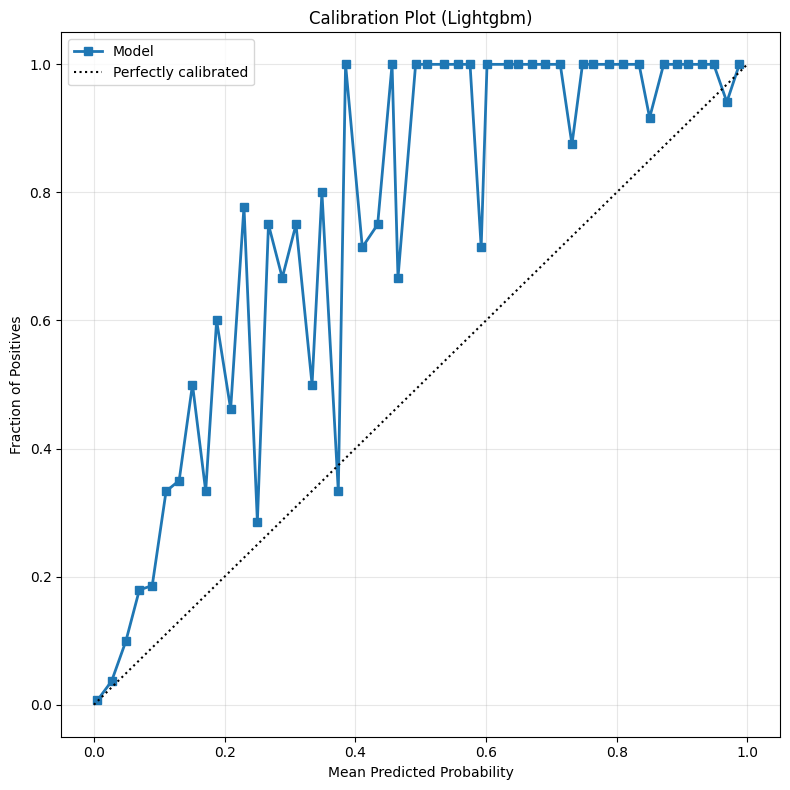

In [8]:
    plot_calibration_curve(reference_data, f" ({model_type.replace('_', ' ').title()})")

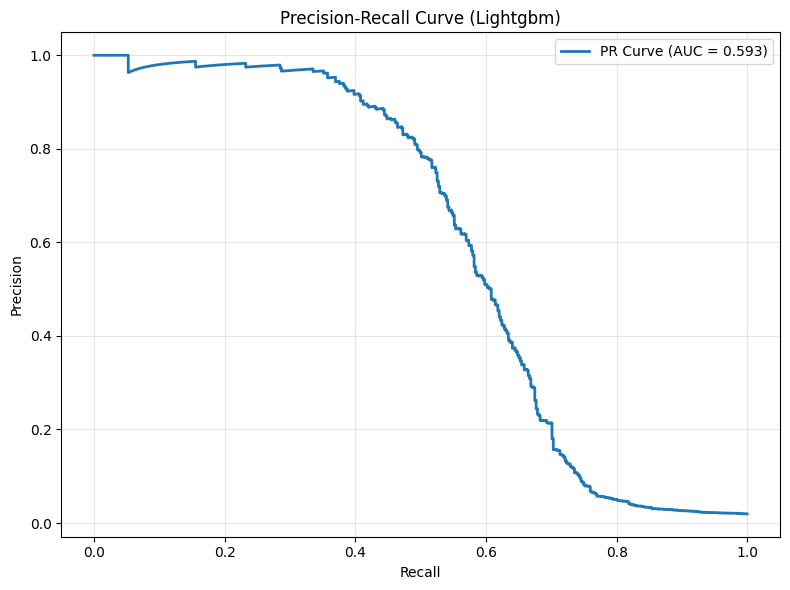

In [9]:
plot_precision_recall_curve(reference_data, f" ({model_type.replace('_', ' ').title()})")

In [7]:
pipeline_params = results[0]['parameters']
create_synthetic_data_summary_table(reference_data, pipeline_params)

,Metric,Value
0,Total Transactions,25000
1,True Fraud Rate,0.0198
2,N Samples,50000
3,N Features,30
4,N Informative,15
5,N Redundant,5
6,Model Type,ModelType.LIGHTGBM
7,Test Size,0.5
8,Class Sep,1.0


In [ ]:
create_policy_metrics_table(results, comparison_key='exploration_rate')

,exploration_rate,allow_rate,block_rate,fraud_rate_overall,fraud_rate_allowed,total_transactions,allowed_transactions,blocked_transactions,model_roc_auc,model_precision,model_recall,model_f1
0,0.0100,0.97644,0.02356,0.0198,0.008070,25000,24411,589,0.845582,0.505942,0.60202,0.549815
1,0.0575,0.97724,0.02276,0.0198,0.008432,25000,24431,569,0.845582,0.505942,0.60202,0.549815
2,0.1050,0.97828,0.02172,0.0198,0.008914,25000,24457,543,0.845582,0.505942,0.60202,0.549815
3,0.1525,0.97940,0.02060,0.0198,0.009598,25000,24485,515,0.845582,0.505942,0.60202,0.549815
4,0.2000,0.98048,0.01952,0.0198,0.010117,25000,24512,488,0.845582,0.505942,0.60202,0.549815


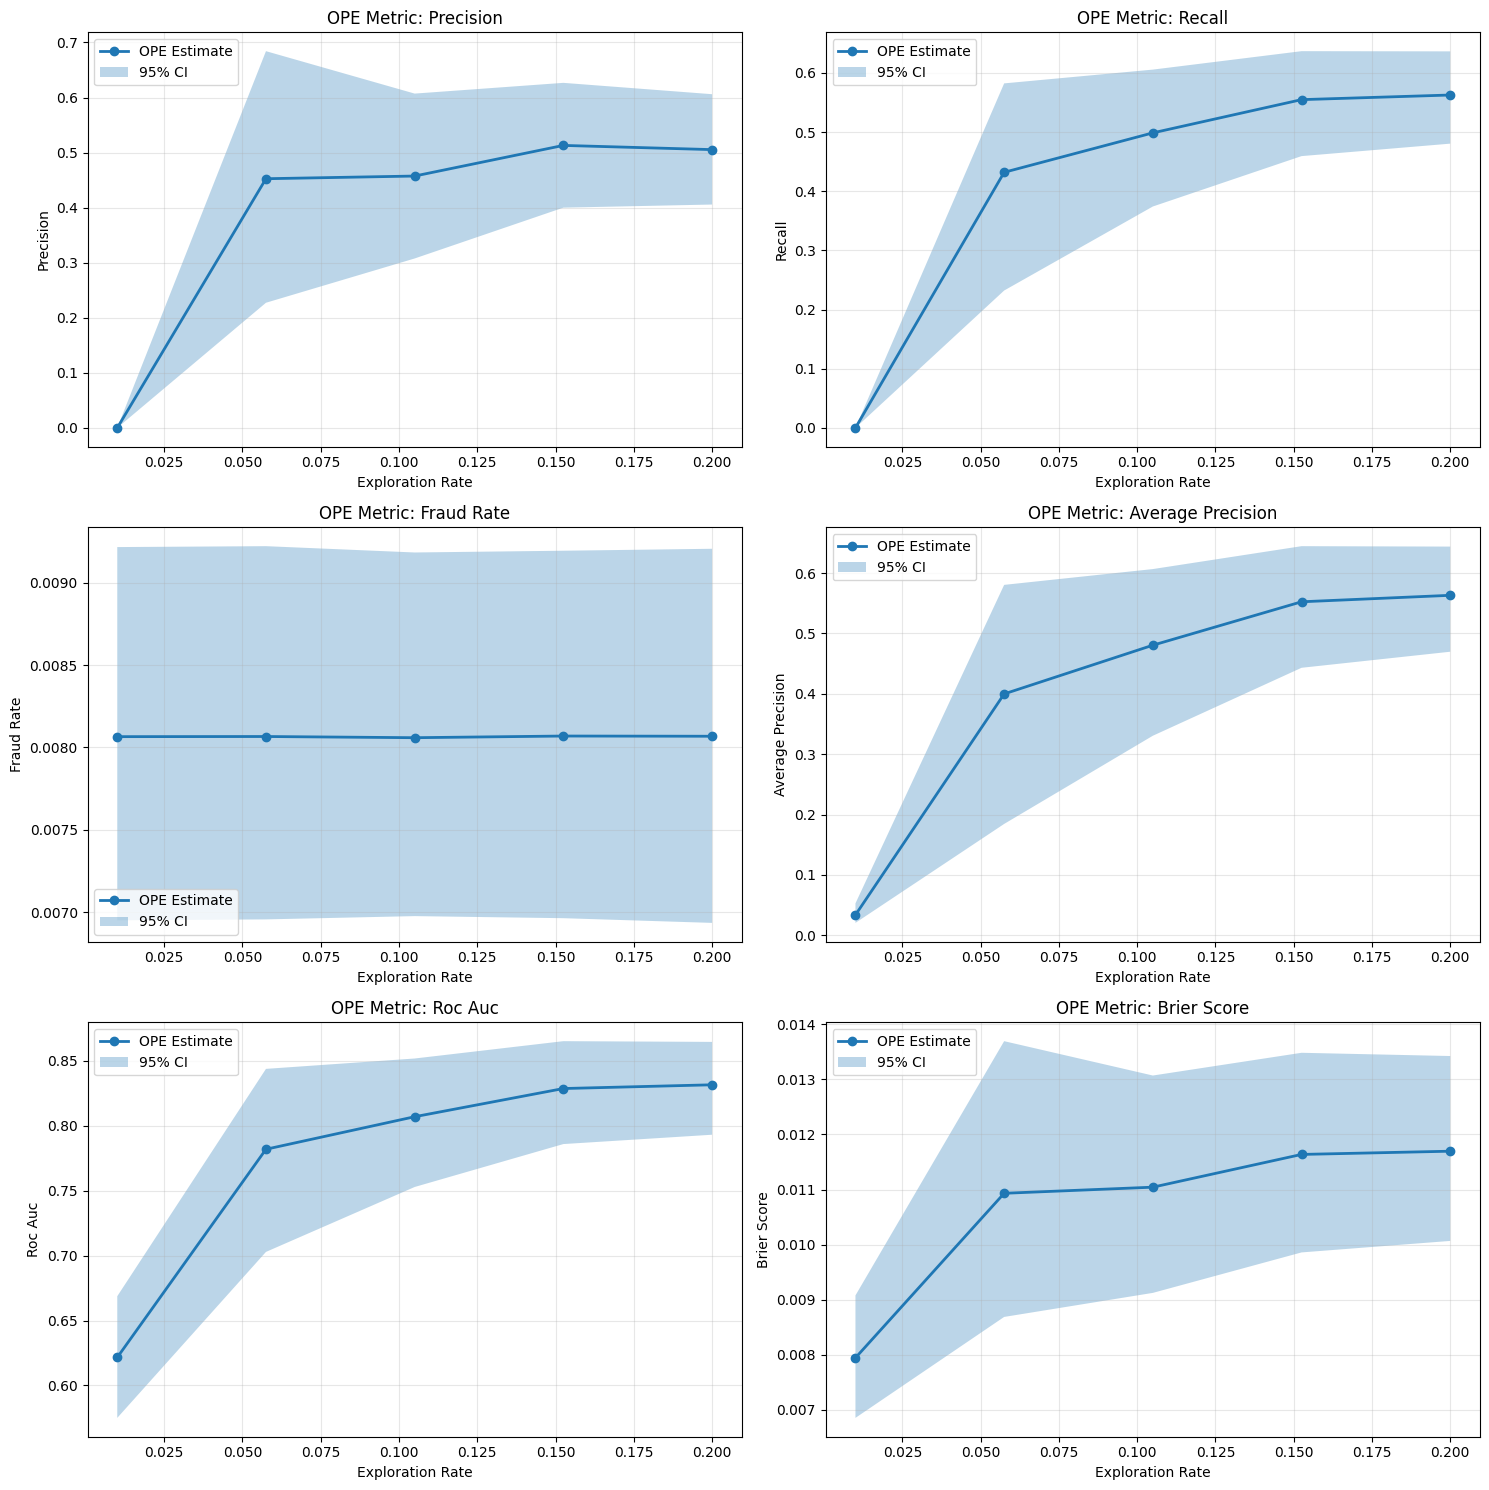

In [ ]:
# TODO: include true baseline for synthetic pipeline
plot_ope_metrics(results, comparison_key='exploration_rate', include_model_baseline=False)

## Synthetic Retraining Simulations

In [4]:
# Define simulation parameters
exploration_rates = np.linspace(0.01, 0.1, 5)
strategies = [RetrainingStrategy.FILTERING, RetrainingStrategy.WEIGHTING, RetrainingStrategy.FRAUD_INJECTION]
sample_size = 200_000
random_state = 667
cutoff=0.1

# Run simulations
results, reference_data = run_retraining_simulations(
    exploration_rates=exploration_rates,
    strategies=strategies,
    cutoff=cutoff,
    sample_size=sample_size,
    random_state=random_state
)

Running 15 simulations...
  - Exploration rates: 5 values
  - Retraining strategies: 3 strategies
Running simulations for exploration_rate=0.010
Strategy=filtering simulation
Strategy=weighting simulation
Strategy=fraud_injection simulation
Running simulations for exploration_rate=0.033
Strategy=filtering simulation
Strategy=weighting simulation
Strategy=fraud_injection simulation
Running simulations for exploration_rate=0.055
Strategy=filtering simulation
Strategy=weighting simulation
Strategy=fraud_injection simulation
Running simulations for exploration_rate=0.077
Strategy=filtering simulation
Strategy=weighting simulation
Strategy=fraud_injection simulation
Running simulations for exploration_rate=0.100
Strategy=filtering simulation
Strategy=weighting simulation
Strategy=fraud_injection simulation


In [8]:
# Create analyzer
analyzer = RetrainingSimulationAnalyzer(results)

In [6]:
# TODO: improve it to reproduce real metrics results for sanity checking
#analyzer.create_summary_table()

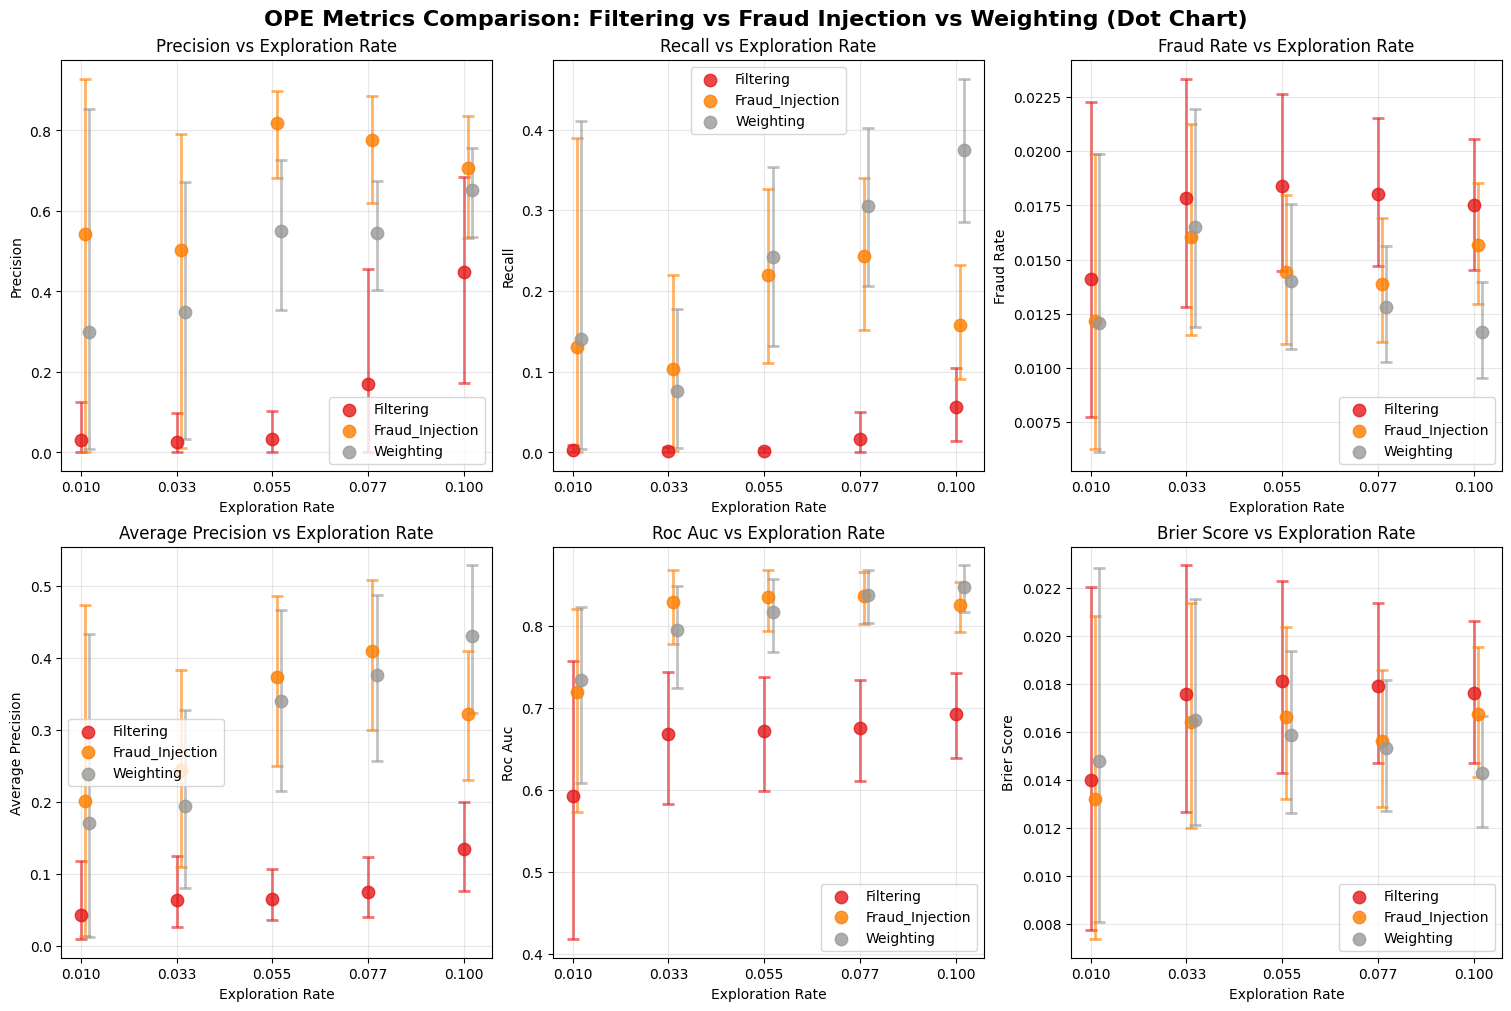

In [9]:
fig_dot = analyzer.plot_dot_chart()